# ANIP - Tâche 1 : Reconnaissance Faciale Robuste
## Face Matching/Verification

Ce notebook implémente un réseau siamois (Siamese Network) pour la reconnaissance et vérification faciale.

## 1. Imports et Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.layers import Dense, Lambda, GlobalAveragePooling2D, Dropout
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean

print("🎯 ANIP - Tâche 1: Reconnaissance Faciale\n")

2025-10-15 15:02:22.119571: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


🎯 ANIP - Tâche 1: Reconnaissance Faciale



In [2]:
# Configuration
DATA_PATH = Path('/Users/mac/development/DATA/anip/anip-age-estimation-kit/anip-reconnaissance-faciale-estimation-ages-ocr/dataset_tache_1/dataset_tache_1')  # --- IGNORE ---
TRAIN_PATH = DATA_PATH / 'train'
TEST_PATH = DATA_PATH / 'test'

IMG_SIZE = (160, 160)  # Taille standard pour face recognition
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Chargement et Analyse des Données

In [3]:
def parse_train_filename(filepath):
    """
    Parse le nom de fichier du train set
    Format: XXXX_Y.jpg où XXXX=person_id, Y=photo_num (0 ou 1)
    """
    filename = filepath.stem
    parts = filename.split('_')
    person_id = int(parts[0])
    photo_num = int(parts[1])
    return person_id, photo_num

def load_train_data():
    """Charge les données d'entraînement"""
    train_images = list(TRAIN_PATH.glob('*.jpg')) + list(TRAIN_PATH.glob('*.JPG'))
    
    data = []
    for img_path in train_images:
        person_id, photo_num = parse_train_filename(img_path)
        data.append({
            'filepath': str(img_path),
            'person_id': person_id,
            'photo_num': photo_num
        })
    
    df = pd.DataFrame(data)
    return df

In [4]:
print("📂 Chargement des données...")
df_train = load_train_data()

print(f"✅ Images d'entraînement: {len(df_train)}")
print(f"   Personnes uniques: {df_train['person_id'].nunique()}")
print(f"   Photos par personne: {df_train.groupby('person_id').size().mode()[0]}")

📂 Chargement des données...
✅ Images d'entraînement: 4000
   Personnes uniques: 2000
   Photos par personne: 2


## 3. Création de Paires Positives et Négatives

In [5]:
def create_pairs(df, n_positive=1000, n_negative=1000):
    """
    Crée des paires d'images pour l'entraînement
    - Paires positives : même personne
    - Paires négatives : personnes différentes
    """
    pairs = []
    labels = []
    
    # Paires positives (même personne)
    print("Création des paires positives...")
    person_ids = df['person_id'].unique()
    
    for _ in tqdm(range(n_positive)):
        person_id = np.random.choice(person_ids)
        person_imgs = df[df['person_id'] == person_id]['filepath'].values
        
        if len(person_imgs) >= 2:
            img1, img2 = np.random.choice(person_imgs, 2, replace=False)
            pairs.append([img1, img2])
            labels.append(1)  # Même personne
    
    # Paires négatives (personnes différentes)
    print("Création des paires négatives...")
    for _ in tqdm(range(n_negative)):
        person_id1, person_id2 = np.random.choice(person_ids, 2, replace=False)
        
        img1 = df[df['person_id'] == person_id1]['filepath'].values[0]
        img2 = df[df['person_id'] == person_id2]['filepath'].values[0]
        
        pairs.append([img1, img2])
        labels.append(0)  # Personnes différentes
    
    return np.array(pairs), np.array(labels)

In [6]:
# Créer les paires
pairs, labels = create_pairs(df_train, n_positive=2000, n_negative=2000)
print(f"\n✅ Paires créées: {len(pairs)}")
print(f"   Positives: {labels.sum()}")
print(f"   Négatives: {len(labels) - labels.sum()}")

# Split train/validation
pairs_train, pairs_val, labels_train, labels_val = train_test_split(
    pairs, labels, test_size=0.2, random_state=SEED
)

Création des paires positives...


100%|██████████| 2000/2000 [00:00<00:00, 3450.22it/s]


Création des paires négatives...


100%|██████████| 2000/2000 [00:00<00:00, 2049.95it/s]


✅ Paires créées: 4000
   Positives: 2000
   Négatives: 2000


## 4. Générateur de Données

In [23]:
def load_and_preprocess_image(image_path, img_size=IMG_SIZE):
    """Charge et prétraite une image"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    img = img.astype('float32') / 255.0
    return img

def pair_generator(pairs, labels, batch_size=32, shuffle=True):
    """Générateur de paires d'images"""
    n_samples = len(pairs)
    indices = np.arange(n_samples)
    
    while True:
        if shuffle:
            np.random.shuffle(indices)
        
        for start_idx in range(0, n_samples, batch_size):
            batch_indices = indices[start_idx:start_idx+batch_size]
            
            batch_pairs = pairs[batch_indices]
            batch_labels = labels[batch_indices]
            
            # Charger les images
            batch_img1 = [load_and_preprocess_image(p[0]) for p in batch_pairs]
            batch_img2 = [load_and_preprocess_image(p[1]) for p in batch_pairs]
            
            yield ((np.array(batch_img1), np.array(batch_img2)), np.array(batch_labels))

## 5. Modèle Siamois (Siamese Network)

In [24]:
def create_base_network(input_shape):
    """Réseau de base pour extraire les features"""
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base_model.trainable = False
    
    inputs = Input(shape=input_shape)
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    embeddings = Dense(128, activation='linear')(x)  # Embedding vector
    
    model = Model(inputs=inputs, outputs=embeddings, name='base_network')
    return model

def create_siamese_network(input_shape):
    """Crée un réseau siamois pour la vérification de visages"""
    
    # Réseau de base partagé
    base_network = create_base_network(input_shape)
    
    # Entrées
    input_a = Input(shape=input_shape, name='input_a')
    input_b = Input(shape=input_shape, name='input_b')
    
    # Passer les deux images dans le même réseau
    embedding_a = base_network(input_a)
    embedding_b = base_network(input_b)
    
    # Calculer la distance L1
    l1_distance = Lambda(lambda x: tf.abs(x[0] - x[1]))([embedding_a, embedding_b])
    
    # Prédiction finale
    prediction = Dense(1, activation='sigmoid')(l1_distance)
    
    # Créer le modèle
    siamese_model = Model(inputs=[input_a, input_b], outputs=prediction)
    
    return siamese_model, base_network

In [25]:
# Créer le modèle
print("\n🧠 Création du modèle siamois...")
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)
siamese_model, base_network = create_siamese_network(input_shape)

siamese_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Modèle créé")
siamese_model.summary()


🧠 Création du modèle siamois...
✅ Modèle créé


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_a             │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_b             │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ base_network        │ (None, 128)       │  2,618,816 │ input_a[0][0],    │
│ (Functional)        │                   │            │ input_b[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128)       │          0 │ base_network[0][… │
│                     │                   │            │ base_network[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │        129 │ lambda_3[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Entraînement

In [26]:
print("\n🎯 Entraînement du modèle...")

steps_per_epoch = len(pairs_train) // BATCH_SIZE
validation_steps = len(pairs_val) // BATCH_SIZE

train_gen = pair_generator(pairs_train, labels_train, BATCH_SIZE)
val_gen = pair_generator(pairs_val, labels_val, BATCH_SIZE, shuffle=False)

# Callbacks
callbacks = [
   keras.callbacks.ModelCheckpoint(
    'best_siamese_model.keras',  # <-- extension corrigée
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history = siamese_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Entraînement terminé!")


🎯 Entraînement du modèle...
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.4941 - loss: 0.9361
Epoch 1: val_accuracy improved from -inf to 0.54125, saving model to best_siamese_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 99s 910ms/step - accuracy: 0.4942 - loss: 0.9350 - val_accuracy: 0.5412 - val_loss: 0.6995 - learning_rate: 1.0000e-04
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.5349 - loss: 0.7096
Epoch 2: val_accuracy improved from 0.54125 to 0.56500, saving model to best_siamese_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.5351 - loss: 0.7095 - val_accuracy: 0.5650 - val_loss: 0.6813 - learning_rate: 1.0000e-04
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.6003 - loss: 0.6645
Epoch 3: val_accuracy improved from 0.56500 to 0.59250, saving model to best_siamese_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6003 - loss: 0.6644 - val_accuracy: 0.5925 - val_loss: 0.6695 - learn

## 7. Extraction d'Embeddings

In [27]:
def get_embeddings_for_all_images(df, base_network, batch_size=32):
    """Calcule les embeddings pour toutes les images"""
    embeddings = []
    filepaths = df['filepath'].values
    
    print("\n📊 Extraction des embeddings...")
    for i in tqdm(range(0, len(filepaths), batch_size)):
        batch_paths = filepaths[i:i+batch_size]
        batch_images = np.array([load_and_preprocess_image(p) for p in batch_paths])
        
        batch_embeddings = base_network.predict(batch_images, verbose=0)
        embeddings.extend(batch_embeddings)
    
    return np.array(embeddings)

# Calculer les embeddings pour le train set
train_embeddings = get_embeddings_for_all_images(df_train, base_network)

# Ajouter les embeddings au DataFrame
df_train['embedding'] = list(train_embeddings)

print("✅ Embeddings calculés")


📊 Extraction des embeddings...


100%|██████████| 125/125 [01:12<00:00,  1.73it/s]

✅ Embeddings calculés


## 8. Prédiction sur le Test Set

In [28]:
def find_matches_in_test(test_path, base_network, threshold=0.5):
    """
    Trouve les paires correspondantes dans le test set
    """
    test_images = list(test_path.glob('*.jpg')) + list(test_path.glob('*.JPG'))
    print(f"\n🔍 Test images: {len(test_images)}")
    
    # Calculer les embeddings pour le test
    test_data = []
    test_embeddings = []
    
    print("Extraction des embeddings du test set...")
    for img_path in tqdm(test_images):
        img = load_and_preprocess_image(str(img_path))
        embedding = base_network.predict(np.expand_dims(img, axis=0), verbose=0)[0]
        
        test_data.append({
            'filepath': str(img_path),
            'filename': img_path.name,
            'embedding': embedding
        })
        test_embeddings.append(embedding)
    
    df_test = pd.DataFrame(test_data)
    
    # Trouver les paires
    print("\nRecherche de paires...")
    matches = []
    n_test = len(df_test)
    
    for i in tqdm(range(n_test)):
        for j in range(i+1, n_test):
            emb1 = df_test.iloc[i]['embedding']
            emb2 = df_test.iloc[j]['embedding']
            
            # Calculer la similarité cosine
            similarity = 1 - cosine(emb1, emb2)
            
            if similarity > threshold:
                matches.append({
                    'image1': df_test.iloc[i]['filename'],
                    'image2': df_test.iloc[j]['filename'],
                    'similarity': similarity,
                    'is_match': 1
                })
    
    matches_df = pd.DataFrame(matches)
    return matches_df, df_test

# Prédire sur le test set
matches_df, df_test = find_matches_in_test(TEST_PATH, base_network, threshold=0.6)

print(f"\n✅ Paires trouvées: {len(matches_df)}")


🔍 Test images: 2000
Extraction des embeddings du test set...


100%|██████████| 2000/2000 [02:29<00:00, 13.41it/s]



Recherche de paires...


100%|██████████| 2000/2000 [03:01<00:00, 11.00it/s] 



✅ Paires trouvées: 53791


## 9. Création du Fichier de Soumission

In [29]:
# Sauvegarder les résultats
matches_df.to_csv('tache1_submission.csv', index=False)
print(f"\n✅ Soumission sauvegardée: tache1_submission.csv")
print(f"\n📊 Aperçu:")
print(matches_df.head(10))


✅ Soumission sauvegardée: tache1_submission.csv

📊 Aperçu:
       image1      image2  similarity  is_match
0  3763_1.jpg  3462_1.jpg    0.675970         1
1  3763_1.jpg  3396_0.jpg    0.698922         1
2  3763_1.jpg  3193_1.jpg    0.630831         1
3  3763_1.jpg  3012_0.jpg    0.715621         1
4  3763_1.jpg  3073_1.jpg    0.641933         1
5  3763_1.jpg  3830_0.jpg    0.655205         1
6  3763_1.jpg  3622_1.jpg    0.741395         1
7  3763_1.jpg  3995_0.jpg    0.698359         1
8  3763_1.jpg  3787_1.jpg    0.671130         1
9  3763_1.jpg  3971_1.jpg    0.625727         1


## 10. Visualisation des Résultats


📊 Visualisation de quelques paires...
✅ Visualisation sauvegardée: tache1_matches_visualization.png


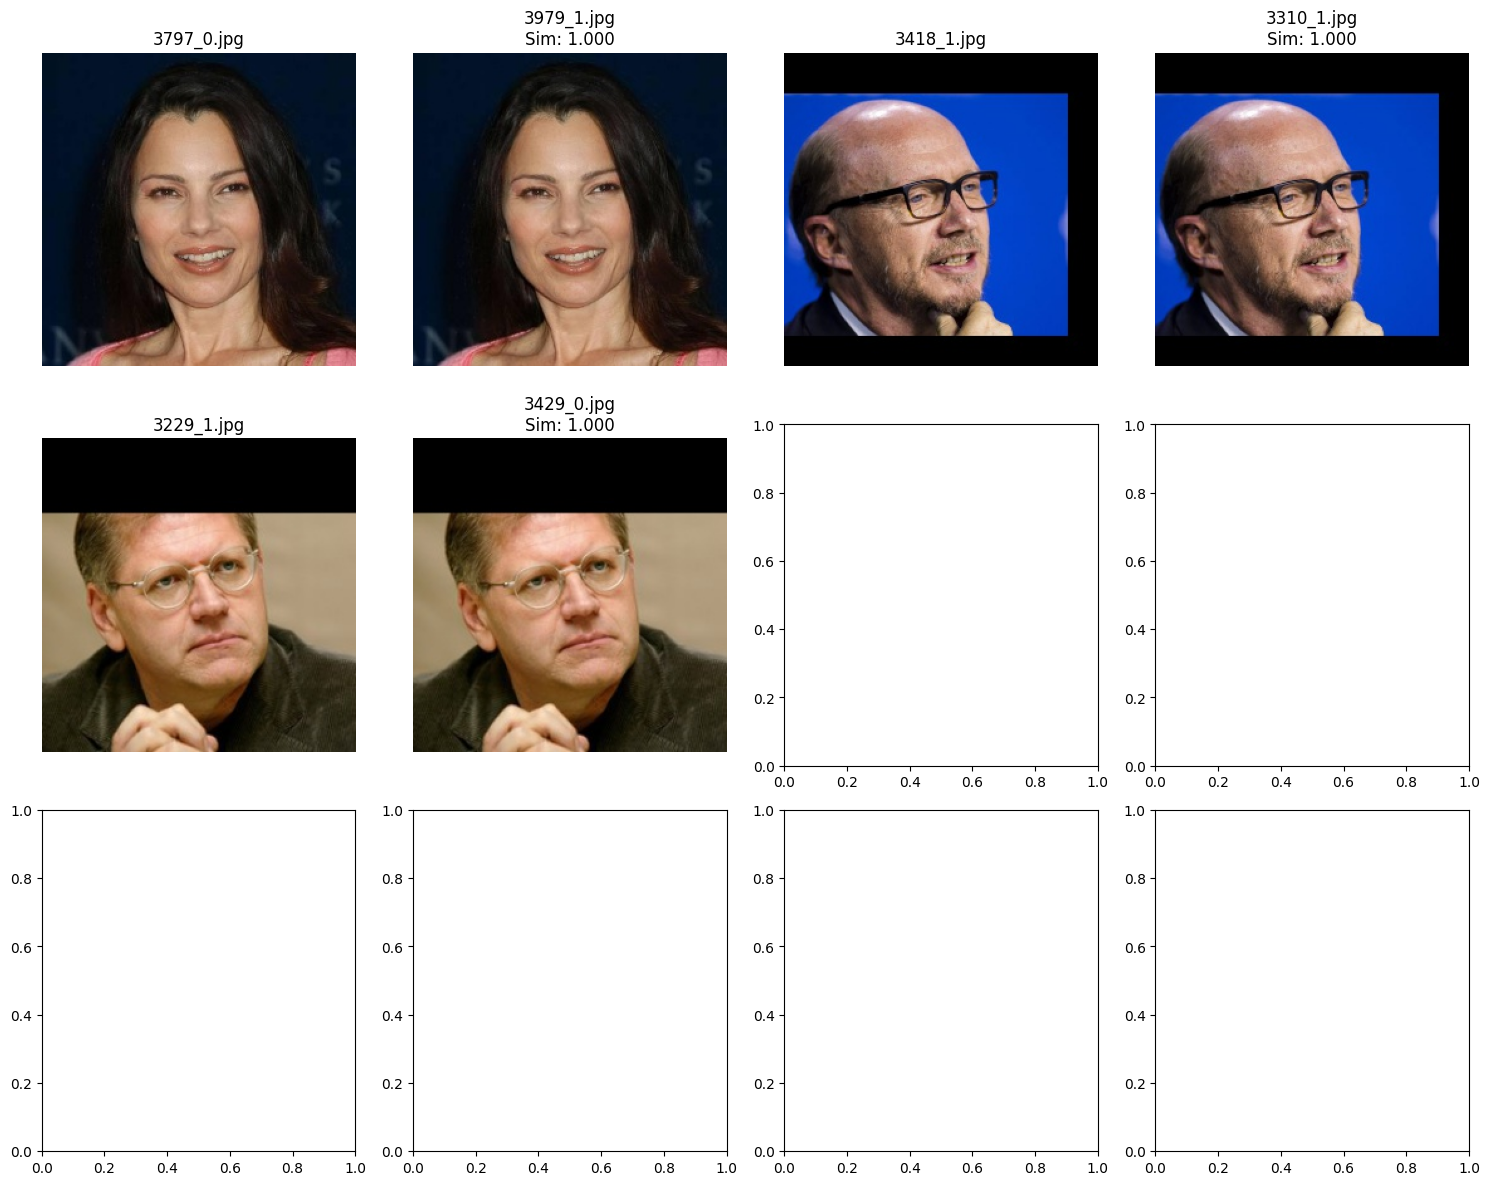

In [30]:
print("\n📊 Visualisation de quelques paires...")

# Sélectionner quelques paires
sample_matches = matches_df.sort_values('similarity', ascending=False).head(6)

fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for idx, (_, row) in enumerate(sample_matches.iterrows()):
    if idx >= 3:
        break
    
    img1_path = TEST_PATH / row['image1']
    img2_path = TEST_PATH / row['image2']
    
    img1 = cv2.imread(str(img1_path))
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    
    img2 = cv2.imread(str(img2_path))
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    axes[idx*2].imshow(img1)
    axes[idx*2].set_title(f"{row['image1']}")
    axes[idx*2].axis('off')
    
    axes[idx*2+1].imshow(img2)
    axes[idx*2+1].set_title(f"{row['image2']}\nSim: {row['similarity']:.3f}")
    axes[idx*2+1].axis('off')

plt.tight_layout()
plt.savefig('tache1_matches_visualization.png', dpi=150, bbox_inches='tight')
print("✅ Visualisation sauvegardée: tache1_matches_visualization.png")